
# Support Vector Regression (SVR)

## 1. Import Libraries

In [1]:

import pandas as pd
import numpy as np

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt


## 2. Create Dataset

In [2]:

data = {
    'Experience': [1,2,3,4,5,6],
    'Salary': [25,30,35,45,50,60]
}

df = pd.DataFrame(data)

df


,Experience,Salary
0,1,25
1,2,30
2,3,35
3,4,45
4,5,50
5,6,60


## 3. Features and Target

In [14]:

X = df[['Experience']]
y = df['Salary']

print("Features")
display(X)

print("\nTarget")
display(y)


Features


,Experience
0,1
1,2
2,3
3,4
4,5
5,6



Target


,Salary
0,25
1,30
2,35
3,45
4,50
5,60



## 4. Feature Scaling

SVR is distance-based.
Therefore feature scaling is important.


In [4]:

sc_X = StandardScaler()
sc_y = StandardScaler()

X_scaled = sc_X.fit_transform(X)

y_scaled = sc_y.fit_transform(
    np.array(y).reshape(-1,1)
)

print("Scaled X")
print(X_scaled)

print("\nScaled y")
print(y_scaled)


Scaled X
[[-1.46385011]
 [-0.87831007]
 [-0.29277002]
 [ 0.29277002]
 [ 0.87831007]
 [ 1.46385011]]

Scaled y
[[-1.31425748]
 [-0.8992288 ]
 [-0.48420012]
 [ 0.34585723]
 [ 0.76088591]
 [ 1.59094327]]



## 5. Create SVR Model

Parameters:
- kernel
- C
- epsilon


In [5]:

model = SVR(
    kernel='linear',
    C=100,
    epsilon=0.1
)

model


SVR(C=100, kernel='linear')

## 6. Train the Model

In [6]:

model.fit(
    X_scaled,
    y_scaled.ravel()
)

print("SVR Model Trained Successfully")


SVR Model Trained Successfully



## 7. Support Vectors

These are important data points that define the model.


In [7]:

print("Support Vector Indices")
print(model.support_)

print("\nSupport Vectors")
print(model.support_vectors_)


Support Vector Indices
[0 2 4 5]

Support Vectors
[[-1.46385011]
 [-0.29277002]
 [ 0.87831007]
 [ 1.46385011]]



## 8. Predict New Data

Predict salary for Experience = 4.5


In [8]:

new_data = [[4.5]]

new_scaled = sc_X.transform(new_data)

prediction_scaled = model.predict(new_scaled)

prediction = sc_y.inverse_transform(
    prediction_scaled.reshape(-1,1)
)

print("Predicted Salary:", prediction[0][0])


Predicted Salary: 47.77855197662287


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 9. Predictions on Training Data

In [9]:

pred_scaled = model.predict(X_scaled)

predictions = sc_y.inverse_transform(
    pred_scaled.reshape(-1,1)
)

results = pd.DataFrame({
    'Actual Salary': y,
    'Predicted Salary': predictions.flatten()
})

results


,Actual Salary,Predicted Salary
0,25,23.795264
1,30,30.647632
2,35,37.500000
3,45,44.352368
4,50,51.204736
5,60,58.057104


## 10. Visualize SVR Regression

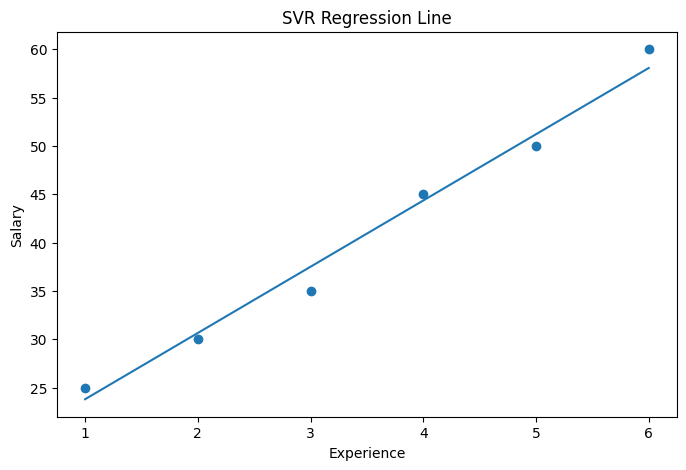

In [10]:

plt.figure(figsize=(8,5))

plt.scatter(X, y)

plt.plot(X, predictions)

plt.xlabel("Experience")
plt.ylabel("Salary")

plt.title("SVR Regression Line")

plt.show()


## 11. Visualize Support Vectors

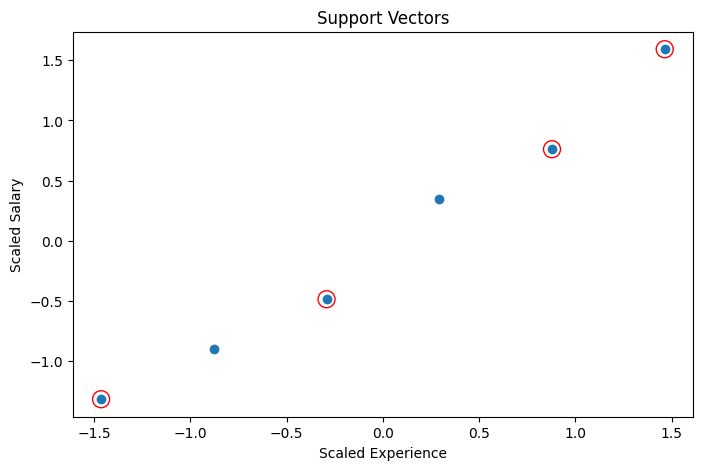

In [11]:

plt.figure(figsize=(8,5))

plt.scatter(X_scaled, y_scaled)

plt.scatter(
    model.support_vectors_,
    y_scaled[model.support_],
    s=150,
    facecolors='none',
    edgecolors='red'
)

plt.xlabel("Scaled Experience")
plt.ylabel("Scaled Salary")

plt.title("Support Vectors")

plt.show()


## 12. Evaluation Metrics

In [12]:

mse = mean_squared_error(y, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y, predictions)

print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


MSE : 2.294412692955878
RMSE: 1.5147318881425444
R2 Score: 0.9841916063260456



## 13. Epsilon Effect

Smaller epsilon:
- Less tolerance
- More support vectors

Larger epsilon:
- More tolerance
- Fewer support vectors


In [13]:

small_epsilon_model = SVR(
    kernel='linear',
    epsilon=0.01
)

large_epsilon_model = SVR(
    kernel='linear',
    epsilon=1
)

small_epsilon_model.fit(X_scaled, y_scaled.ravel())
large_epsilon_model.fit(X_scaled, y_scaled.ravel())

print("Support vectors with small epsilon:",
      len(small_epsilon_model.support_))

print("Support vectors with large epsilon:",
      len(large_epsilon_model.support_))


Support vectors with small epsilon: 6
Support vectors with large epsilon: 2



# 14. Final Summary

SVR:

- Creates epsilon tube
- Ignores small errors
- Uses support vectors
- Requires feature scaling
- Can handle nonlinear data using kernels
